In [3]:
import pandas as pd
import os

current_dir = os.path.abspath('.')
root_dir = os.path.dirname(current_dir) 
file_path = os.path.join(root_dir, 'data', 'default of credit card clients.csv')
    
# Charger le CSV dans un DataFrame
df = pd.read_csv(file_path)


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print("\nRésumé statistique de toutes les colonnes :")
print(df.describe())



Résumé statistique de toutes les colonnes :
                 ID       LIMIT_BAL           SEX     EDUCATION      MARRIAGE  \
count  30000.000000    30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000   167484.322667      1.603733      1.853133      1.551867   
std     8660.398374   129747.661567      0.489129      0.790349      0.521970   
min        1.000000    10000.000000      1.000000      0.000000      0.000000   
25%     7500.750000    50000.000000      1.000000      1.000000      1.000000   
50%    15000.500000   140000.000000      2.000000      2.000000      2.000000   
75%    22500.250000   240000.000000      2.000000      2.000000      2.000000   
max    30000.000000  1000000.000000      2.000000      6.000000      3.000000   

                AGE         PAY_1         PAY_2         PAY_3         PAY_4  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      35.485500     -0.016700     -0.133767     -0.166200     -

In [5]:
print(f'Nombre de doublons parfaits : {df.duplicated().sum()}')
print(f'Nombre de doublons sur ID : {df['ID'].duplicated().sum()}')

Nombre de doublons parfaits : 0
Nombre de doublons sur ID : 0


In [6]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']


In [7]:
print('Types des colonnnes : ')
df.dtypes

Types des colonnnes : 


ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_1        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
dpnm         int64
dtype: object

In [8]:
print("Valeurs manquantes :")
df.isna().sum()

Valeurs manquantes :


ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dpnm         0
dtype: int64

=== ANALYSE DES ANOMALIES ===

1. Résumé statistique des colonnes PAY_AMT :
            PAY_AMT1      PAY_AMT2      PAY_AMT3       PAY_AMT4  \
count   30000.000000  3.000000e+04   30000.00000   30000.000000   
mean     5663.580500  5.921163e+03    5225.68150    4826.076867   
std     16563.280354  2.304087e+04   17606.96147   15666.159744   
min         0.000000  0.000000e+00       0.00000       0.000000   
25%      1000.000000  8.330000e+02     390.00000     296.000000   
50%      2100.000000  2.009000e+03    1800.00000    1500.000000   
75%      5006.000000  5.000000e+03    4505.00000    4013.250000   
max    873552.000000  1.684259e+06  896040.00000  621000.000000   

            PAY_AMT5       PAY_AMT6  
count   30000.000000   30000.000000  
mean     4799.387633    5215.502567  
std     15278.305679   17777.465775  
min         0.000000       0.000000  
25%       252.500000     117.750000  
50%      1500.000000    1500.000000  
75%      4031.500000    4000.000000  
max    426529.00

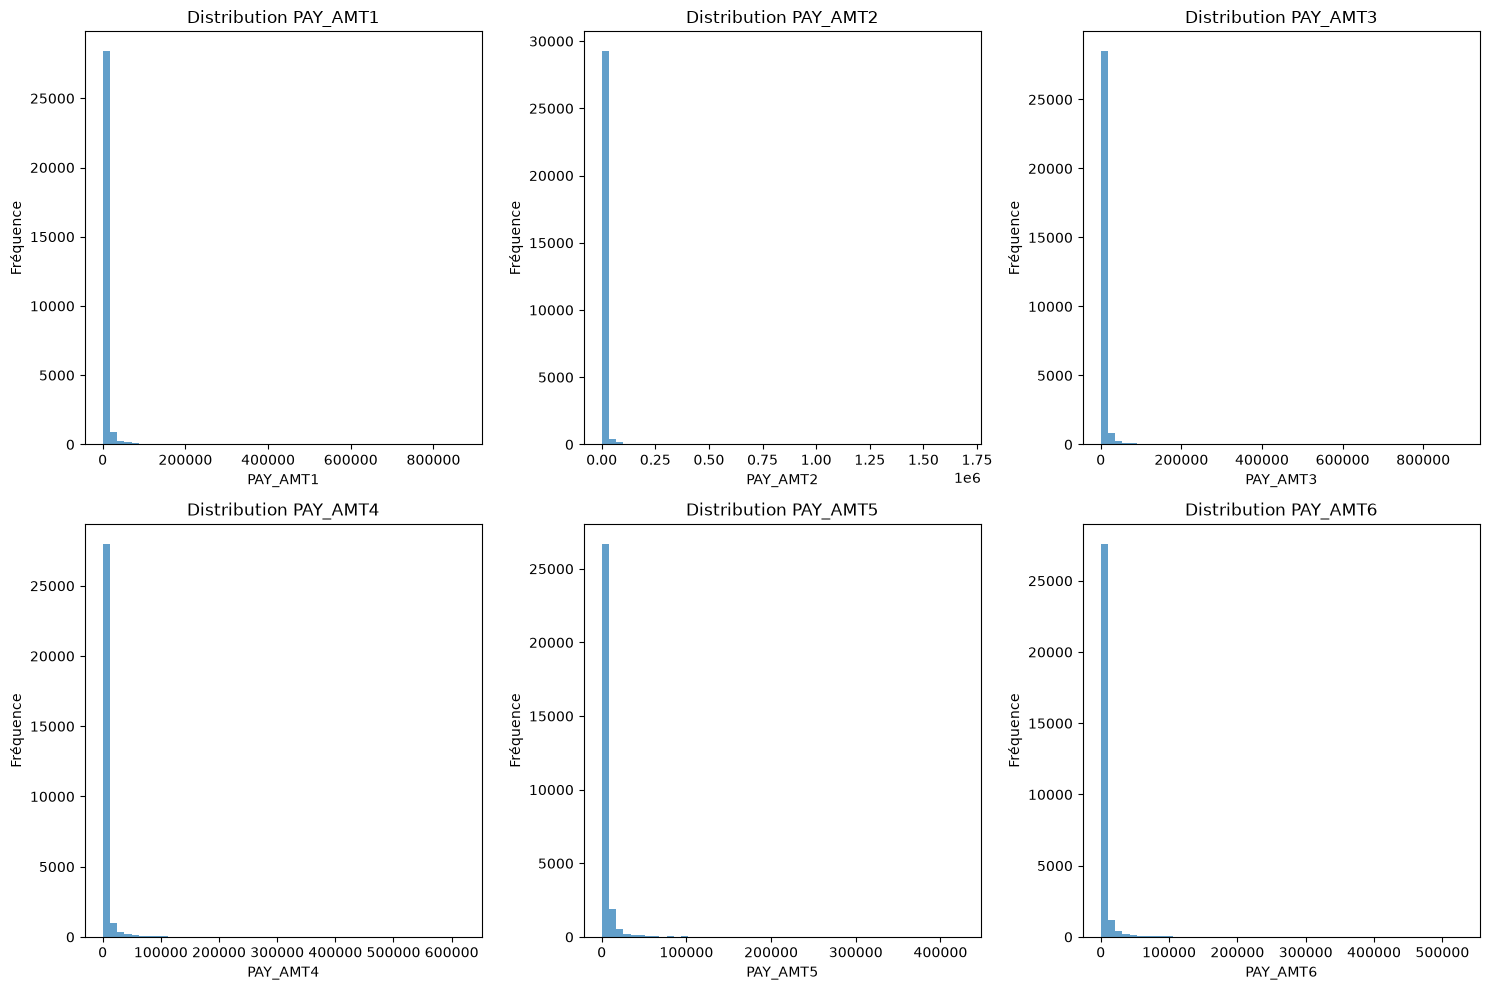

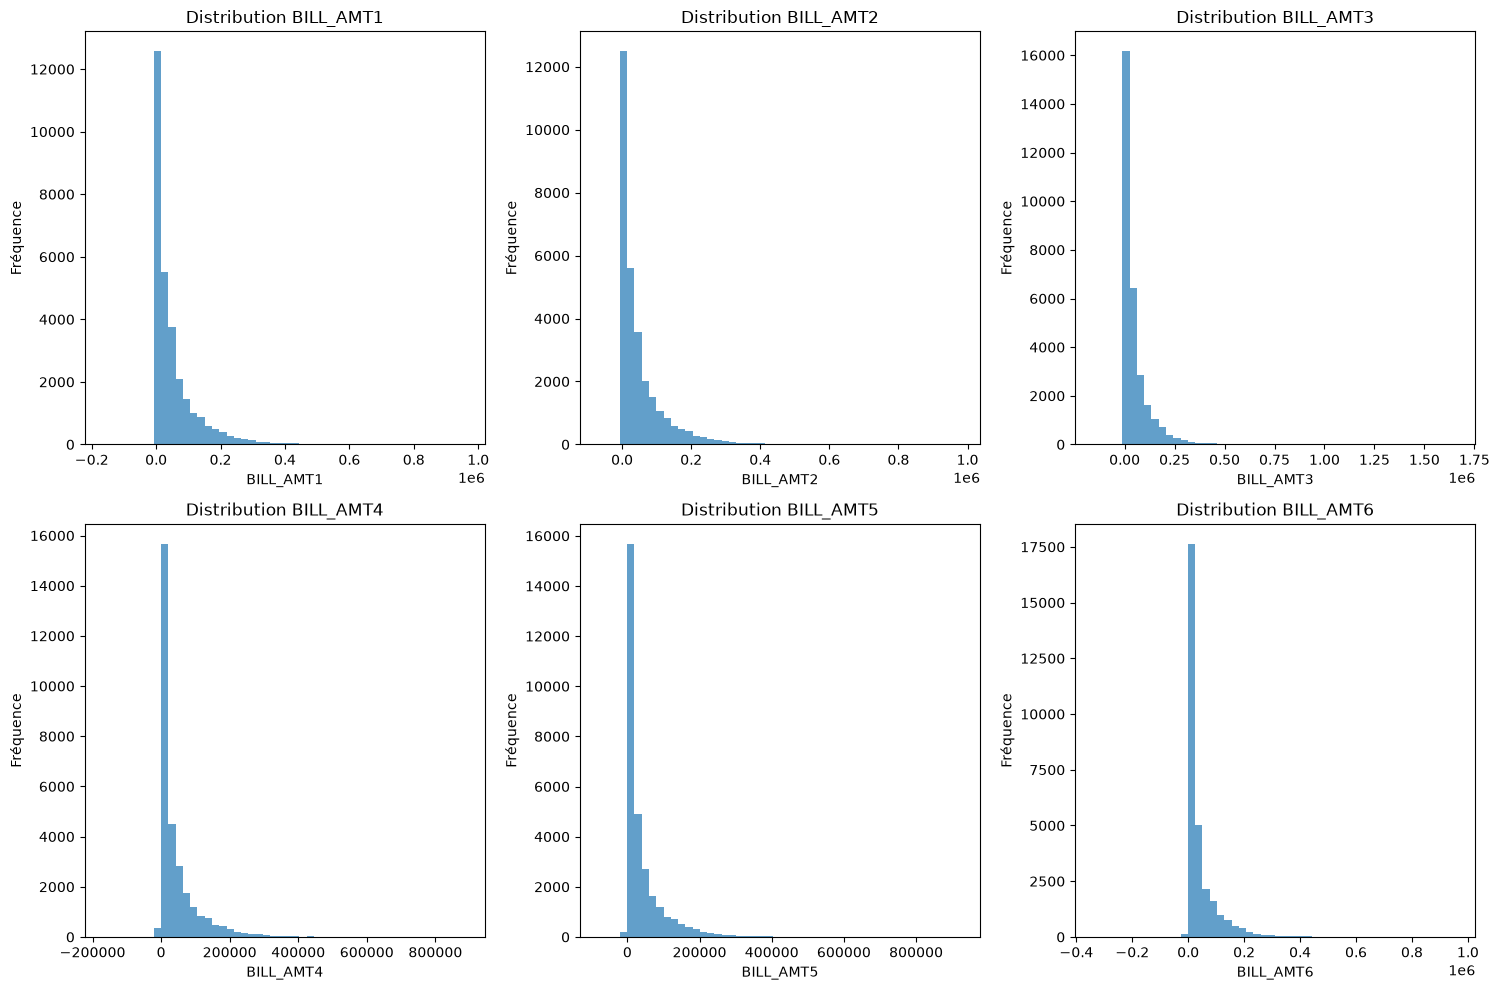

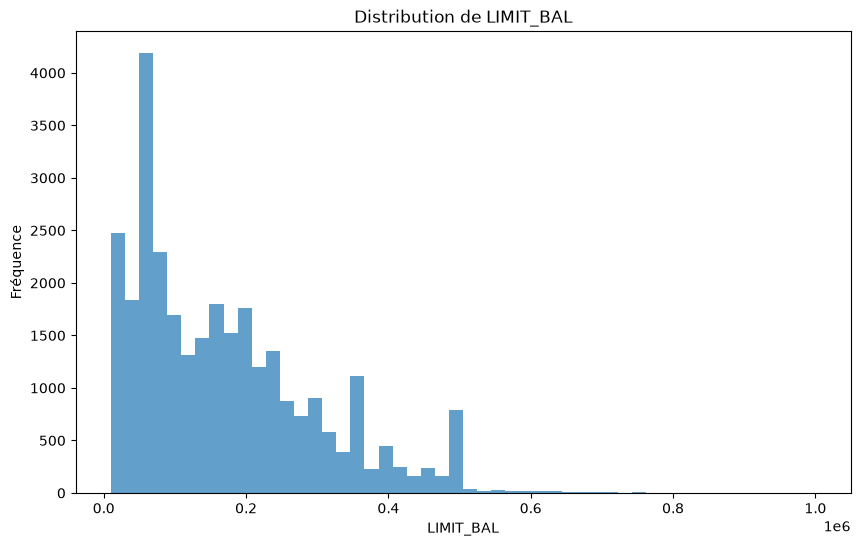

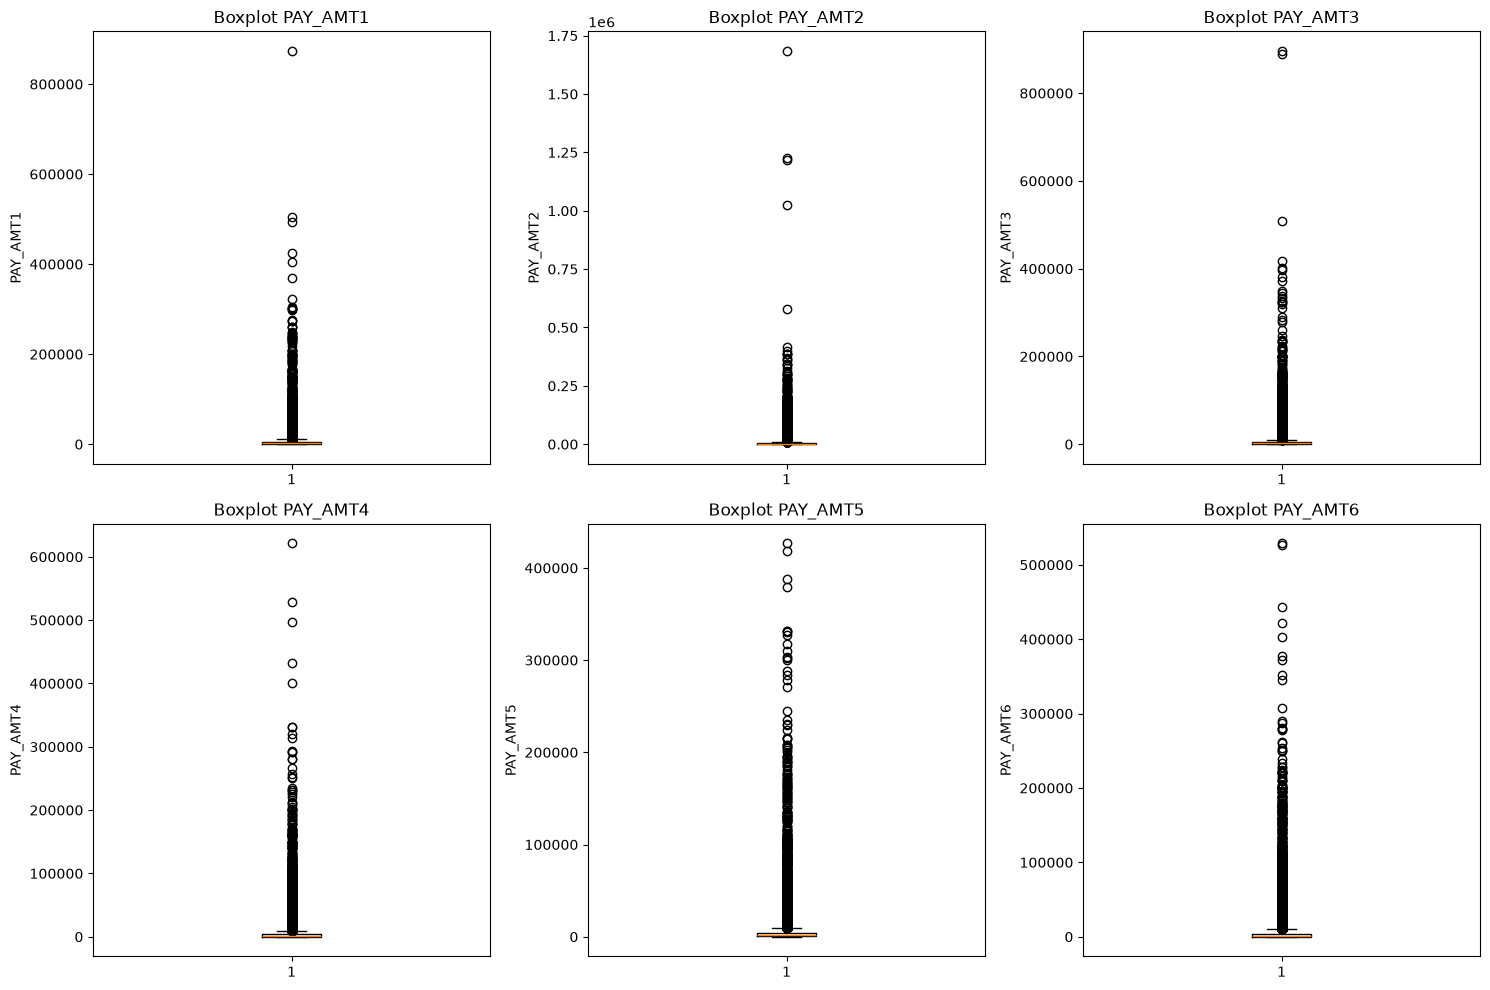

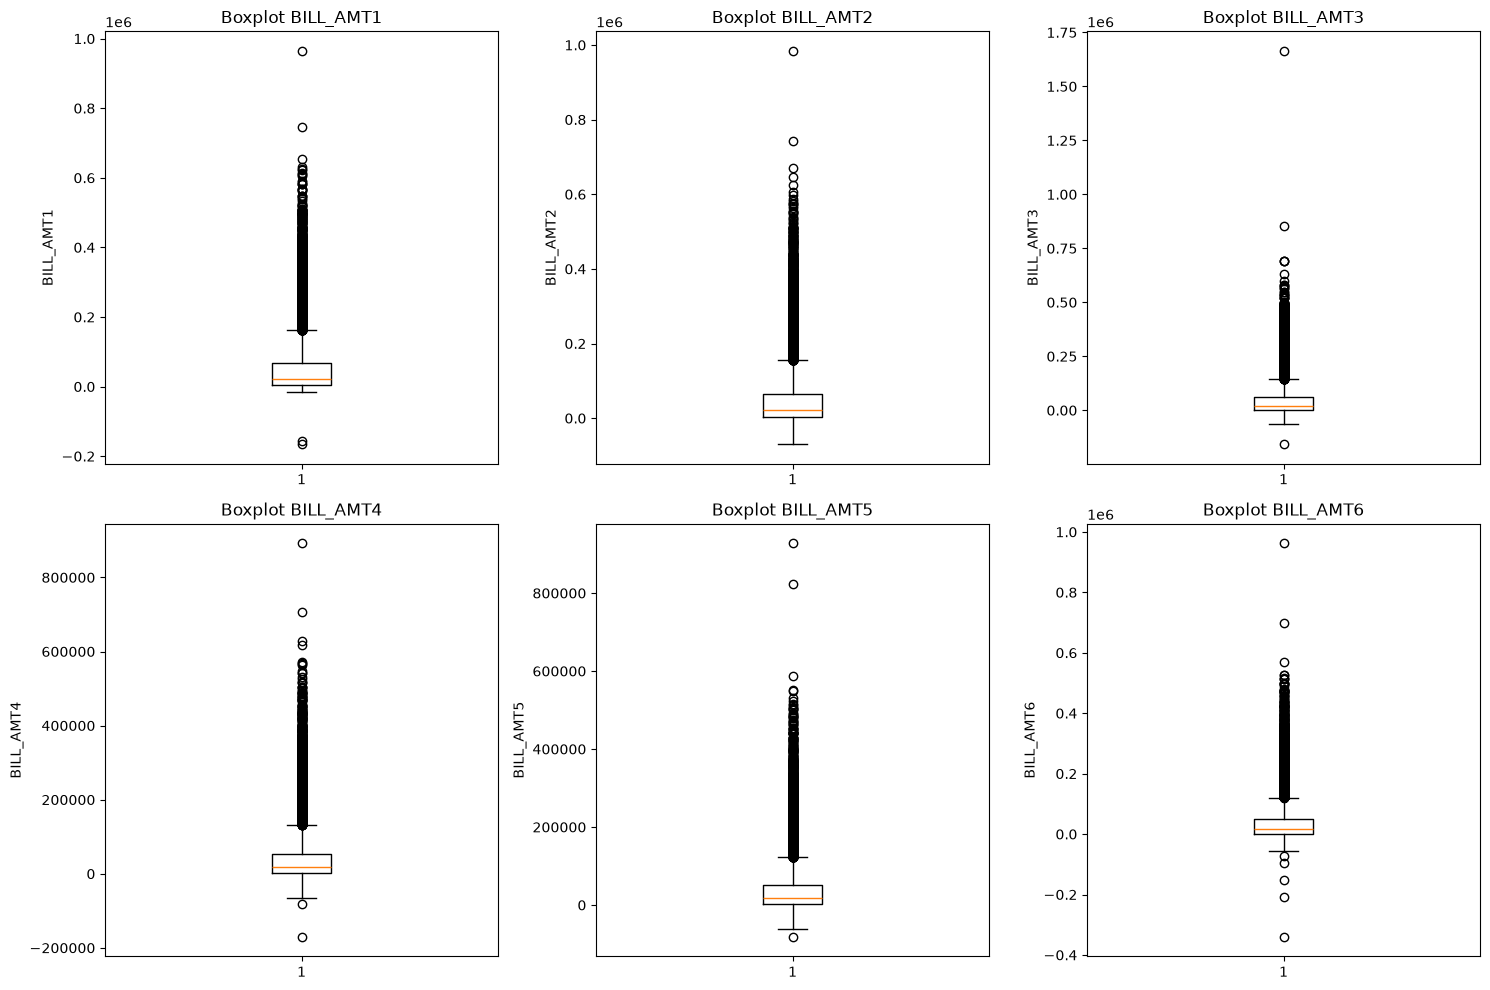

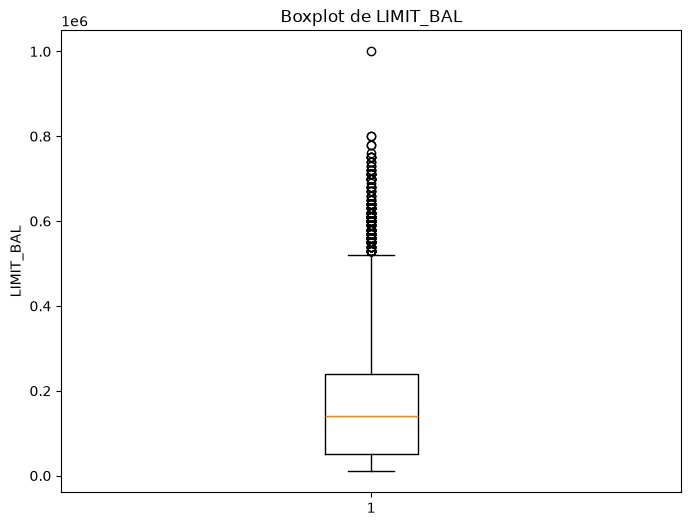


Analyse des anomalies terminée !


In [9]:
import matplotlib.pyplot as plt

# Sélectionner les colonnes PAY_AMT et BILL_AMT
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Analyse des distributions pour chaque colonne
print("=== ANALYSE DES ANOMALIES ===")
print("\n1. Résumé statistique des colonnes PAY_AMT :")
print(df[pay_amt_columns].describe())

print("\n2. Résumé statistique des colonnes BILL_AMT :")
print(df[bill_amt_columns].describe())

print("\n3. Résumé statistique de LIMIT_BAL :")
print(df['LIMIT_BAL'].describe())

# Vérification des valeurs négatives (potentielles anomalies)
print("\n4. Nombre de valeurs négatives par colonne :")
for col in pay_amt_columns:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} valeurs négatives")

for col in bill_amt_columns:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} valeurs négatives")

print(f"LIMIT_BAL: {(df['LIMIT_BAL'] < 0).sum()} valeurs négatives")

# Vérification des valeurs très élevées (outliers)
print("\n5. Analyse des outliers (valeurs au-delà de 3 écarts-types) :")
for col in pay_amt_columns:
    mean_val = df[col].mean()
    std_val = df[col].std()
    threshold = mean_val + 3 * std_val
    outlier_count = (df[col] > threshold).sum()
    print(f"{col}: {outlier_count} outliers (> {threshold:.2f})")

for col in bill_amt_columns:
    mean_val = df[col].mean()
    std_val = df[col].std()
    threshold = mean_val + 3 * std_val
    outlier_count = (df[col] > threshold).sum()
    print(f"{col}: {outlier_count} outliers (> {threshold:.2f})")

print(f"LIMIT_BAL: {(df['LIMIT_BAL'] > (df['LIMIT_BAL'].mean() + 3 * df['LIMIT_BAL'].std())).sum()} outliers")

# Analyse des valeurs à zéro
print("\n6. Nombre de valeurs nulles par colonne :")
for col in pay_amt_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} valeurs nulles")

for col in bill_amt_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} valeurs nulles")

print(f"LIMIT_BAL: {(df['LIMIT_BAL'] == 0).sum()} valeurs nulles")

# Création de visualisations pour identifier les anomalies
print("\n7. Création des visualisations...")

# Distribution des valeurs pour les colonnes PAY_AMT
plt.figure(figsize=(15, 10))
for i, col in enumerate(pay_amt_columns):
    plt.subplot(2, 3, i+1)
    plt.hist(df[col], bins=50, alpha=0.7)
    plt.title(f'Distribution {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

# Distribution des valeurs pour les colonnes BILL_AMT
plt.figure(figsize=(15, 10))
for i, col in enumerate(bill_amt_columns):
    plt.subplot(2, 3, i+1)
    plt.hist(df[col], bins=50, alpha=0.7)
    plt.title(f'Distribution {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

# Distribution de LIMIT_BAL
plt.figure(figsize=(10, 6))
plt.hist(df['LIMIT_BAL'], bins=50, alpha=0.7)
plt.title('Distribution de LIMIT_BAL')
plt.xlabel('LIMIT_BAL')
plt.ylabel('Fréquence')
plt.show()

# Boxplots pour identifier les outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(pay_amt_columns):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col])
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Boxplots pour les colonnes BILL_AMT
plt.figure(figsize=(15, 10))
for i, col in enumerate(bill_amt_columns):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col])
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Boxplot de LIMIT_BAL
plt.figure(figsize=(8, 6))
plt.boxplot(df['LIMIT_BAL'])
plt.title('Boxplot de LIMIT_BAL')
plt.ylabel('LIMIT_BAL')
plt.show()

print("\nAnalyse des anomalies terminée !")

## Anomalies détectées
'EDUCATION' doit etre un entier compris entre 1 et 4, je vois que min est 0 et max est 6 donc tout ce qui n'est pas 1,2,3 ou 4 doit etre ramené à 4 (='autres')  
'PAY_N' ne peut être inférieur à -1 et doit être un entier, le minimum de '-2' est impossible  
'BILL_AMTN' contient des négatifs    
'MARRIAGE' doit etre 1,2 ou 3, tout ce qui est différent sera corrigé en 3 (=autres')
Pour la répartition des valeurs, très peu de grandes valeurs mais qui écrase les graphiques, pas d'anomalie détectée dans le contexte d'une carte de crédit. Je ne modifie pas les quelques valeurs atypiques qui peuvent avoir un comportement dépensier recherché

In [10]:
import numpy as np

# Calculer le pourcentage de valeurs négatives strictes pour chaque colonne
negative_percentage = (df < 0).sum() / len(df) * 100

# Convertir en DataFrame pour un affichage plus clair
result_df = pd.DataFrame({
    'Column_Name': negative_percentage.index,
    'Negative_Percentage': negative_percentage.values
})

# Arrondir les pourcentages à 2 décimales
result_df['Negative_Percentage'] = result_df['Negative_Percentage'].round(2)
print(result_df)


   Column_Name  Negative_Percentage
0           ID                 0.00
1    LIMIT_BAL                 0.00
2          SEX                 0.00
3    EDUCATION                 0.00
4     MARRIAGE                 0.00
5          AGE                 0.00
6        PAY_1                28.15
7        PAY_2                32.77
8        PAY_3                33.41
9        PAY_4                33.45
10       PAY_5                33.62
11       PAY_6                35.45
12   BILL_AMT1                 1.97
13   BILL_AMT2                 2.23
14   BILL_AMT3                 2.18
15   BILL_AMT4                 2.25
16   BILL_AMT5                 2.18
17   BILL_AMT6                 2.29
18    PAY_AMT1                 0.00
19    PAY_AMT2                 0.00
20    PAY_AMT3                 0.00
21    PAY_AMT4                 0.00
22    PAY_AMT5                 0.00
23    PAY_AMT6                 0.00
24        dpnm                 0.00


In [11]:
def analyze_payment_delays(df):
    """
    Analyse les retards de paiement dans les colonnes PAY_*
    Parameters:
    df (pd.DataFrame): DataFrame contenant les colonnes PAY_*
    Returns:
    dict: Résultats de l'analyse
    """
    # Créer la liste des colonnes à analyser
    pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
    print("=== ANALYSE DES RETARDS DE PAIEMENT ===")
    
    # Analyser chaque colonne de paiement
    results = {}
    total_records = len(df)
    
    for col in pay_columns:
        # Compter les valeurs strictement inférieures à -1
        count_less_than_neg1 = (df[col] < -1).sum()
        percentage_less_than_neg1 = (count_less_than_neg1 / total_records) * 100
        
        # Compter les valeurs égales à 0
        count_zeros = (df[col] == 0).sum()
        percentage_zeros = (count_zeros / total_records) * 100
        
        # Statistiques générales
        min_val = df[col].min()
        max_val = df[col].max()
        mean_val = df[col].mean()
        
        results[col] = {
            'count_less_than_neg1': count_less_than_neg1,
            'percentage_less_than_neg1': percentage_less_than_neg1,
            'count_zeros': count_zeros,
            'percentage_zeros': percentage_zeros,
            'min': min_val,
            'max': max_val,
            'mean': mean_val
        }
        
        print(f"\n{col}:")
        print(f"  - Nombre de valeurs < -1: {count_less_than_neg1}")
        print(f"  - Pourcentage < -1: {percentage_less_than_neg1:.2f}%")
        print(f"  - Nombre de valeurs = 0: {count_zeros}")
        print(f"  - Pourcentage = 0: {percentage_zeros:.2f}%")
        print(f"  - Valeur minimale: {min_val}")
        print(f"  - Valeur maximale: {max_val}")
        print(f"  - Moyenne: {mean_val:.2f}")
        
        # Afficher quelques exemples de valeurs < -1
        if count_less_than_neg1 > 0:
            negative_values = df[df[col] < -1][col].head()
            print(f"  - Exemples (< -1): {negative_values.tolist()}")
    
    return results

def analyze_specific_case(df):
    """
    Analyse spécifique pour répondre à ta question
    """
    # Créer la liste des colonnes à analyser
    pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
    print("\n=== ANALYSE SPÉCIFIQUE ===")
    print("Nombre de valeurs strictement inférieures à -1 dans chaque colonne :")
    
    total_negative = 0
    total_zeros = 0
    
    for col in pay_columns:
        count_negative = (df[col] < -1).sum()
        count_zero = (df[col] == 0).sum()
        
        total_negative += count_negative
        total_zeros += count_zero
        
        print(f"  {col}: {count_negative} valeurs < -1, {count_zero} valeurs = 0")
    
    print(f"\nTotal de toutes les valeurs < -1: {total_negative}")
    print(f"Total de toutes les valeurs = 0: {total_zeros}")
    
# Analyse
analyze_payment_delays(df)
    
# Appel de la fonction d'analyse
analyze_specific_case(df)

=== ANALYSE DES RETARDS DE PAIEMENT ===

PAY_1:
  - Nombre de valeurs < -1: 2759
  - Pourcentage < -1: 9.20%
  - Nombre de valeurs = 0: 14737
  - Pourcentage = 0: 49.12%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.02
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_2:
  - Nombre de valeurs < -1: 3782
  - Pourcentage < -1: 12.61%
  - Nombre de valeurs = 0: 15730
  - Pourcentage = 0: 52.43%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.13
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_3:
  - Nombre de valeurs < -1: 4085
  - Pourcentage < -1: 13.62%
  - Nombre de valeurs = 0: 15764
  - Pourcentage = 0: 52.55%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.17
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_4:
  - Nombre de valeurs < -1: 4348
  - Pourcentage < -1: 14.49%
  - Nombre de valeurs = 0: 16455
  - Pourcentage = 0: 54.85%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.22
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_

In [28]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg2 = df[pay_columns].eq(-2).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -2 : {count_all_neg2}")

Nombre de lignes contenant uniquement des -2 : 2109


In [29]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg2 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -2 : {count_at_least_one_neg2}")

Nombre de lignes contenant au moins un -2 : 6561


In [30]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg1 = df[pay_columns].eq(-1).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -1 : {count_all_neg1}")

Nombre de lignes contenant uniquement des -1 : 1992


In [31]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg1 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -1 : {count_at_least_one_neg1}")

Nombre de lignes contenant au moins un -1 : 6561


In [32]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_0 = df[pay_columns].eq(0).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des 0 : {count_all_0}")

Nombre de lignes contenant uniquement des 0 : 9821


In [33]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_0 = df[pay_columns].eq(0).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un 0 : {count_at_least_one_0}")

Nombre de lignes contenant au moins un 0 : 21173


### approche de compréhention  
Je cherche à comprendre à quoi correspondent les valeurs '-2', '-1' et '0' des colonnes 'PAY_n'.  
Ces 3 valeurs signifient-elles la même chose ? Représentent-elles des retards mal saisis ?  
Selon la documentation du dataset, '-1' signifie client à jour et des entiers positifs représentent le nombre de mois de retard de paiement  
Je regarde pour ces 3 valeurs à quoi cela peut correspondre en terme de paiements et d'encours

In [14]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES VALEURS DE PAIEMENT ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n")

# Pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {bill_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne BILL_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== ANALYSE DES VALEURS DE PAIEMENT (PAY_AMT) ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de PAY_AMT_n")

# Pour chaque paire de colonnes PAY_AMT
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {pay_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne PAY_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== STATISTIQUES GÉNÉRALES ===")
# Afficher les statistiques générales pour chaque colonne
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n{pay_col} :")
    print(f"  - Moyenne de {bill_amt_col} : {df[bill_amt_col].mean():.2f}")
    print(f"  - Écart-type de {bill_amt_col} : {df[bill_amt_col].std():.2f}")
    print(f"  - Nombre total de valeurs : {len(df)}")

=== ANALYSE DES VALEURS DE PAIEMENT ===
Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n

--- PAY_1 vs BILL_AMT1 ---
  Moyenne de BILL_AMT1 quand PAY_1 = 0 : 78417.89
  Moyenne de BILL_AMT1 quand PAY_1 = -1 : 10484.80
  Moyenne de BILL_AMT1 quand PAY_1 = -2 : 8793.05
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT1 pour PAY_1 = 0 : [29239, 46990, 64400]
    Valeurs BILL_AMT1 pour PAY_1 = -1 : [2682, 8617, 12261]
    Valeurs BILL_AMT1 pour PAY_1 = -2 : [0, 5512, 10929]

--- PAY_2 vs BILL_AMT2 ---
  Moyenne de BILL_AMT2 quand PAY_2 = 0 : 74629.30
  Moyenne de BILL_AMT2 quand PAY_2 = -1 : 9351.50
  Moyenne de BILL_AMT2 quand PAY_2 = -2 : 5138.20
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT2 pour PAY_2 = 0 : [14027, 48233, 5670]
    Valeurs BILL_AMT2 pour PAY_2 = -1 : [380, 21670, 316]
    Valeurs BILL_AMT2 pour PAY_2 = -2 : [0, 0, 0]

--- PAY_3 vs BILL_AMT3 ---
  Moyenne de BILL_AMT3 quand PAY_3 = 0 : 71547.30
  Moyenne

In [ ]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===")
print("Proportion de valeurs égales à 0 dans PAY_AMT et <=0 dans BILL_AMT pour chaque valeur de PAY_n")

# Analyse pour chaque colonne PAY_n
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    total_records = len(df)
    
    print(f"\n--- {pay_col} ---")
    
    # Pour chaque valeur de PAY_n, calculer la proportion de 0 dans PAY_AMT
    print(f"Proportion de 0 dans {pay_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Même analyse pour BILL_AMT
    print(f"Proportion de <=0 dans {bill_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")

print("\n=== ANALYSE COMPARATIVE ===")
print("Résumé des proportions de 0 pour chaque situation")

# Résumé par situation
situations = ['0', '-1', '-2']
for situation in situations:
    print(f"\n--- Situation {situation} ---")
    
    for i in range(len(pay_columns)):
        pay_col = pay_columns[i]
        pay_amt_col = pay_amt_columns[i]
        bill_amt_col = bill_amt_columns[i]
        
        if situation == '0':
            condition = df[pay_col] == 0
        elif situation == '-1':
            condition = df[pay_col] == -1
        else:  # situation == '-2'
            condition = df[pay_col] == -2
        
        total_with_situation = condition.sum()
        
        if total_with_situation > 0:
            # Pour PAY_AMT
            zeros_in_pay_amt = (condition & (df[pay_amt_col] == 0)).sum()
            percentage_pay_amt = (zeros_in_pay_amt / total_with_situation) * 100
            
            # Pour BILL_AMT
            zeros_in_bill_amt = (condition & (df[bill_amt_col] == 0)).sum()
            percentage_bill_amt = (zeros_in_bill_amt / total_with_situation) * 100
            
            print(f"  {pay_col}: PAY_AMT={percentage_pay_amt:.2f}%, BILL_AMT={percentage_bill_amt:.2f}%")

=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===
Proportion de valeurs égales à 0 dans PAY_AMT et <=0 dans BILL_AMT pour chaque valeur de PAY_n

--- PAY_1 ---
Proportion de 0 dans PAY_AMT1 :
  Quand PAY_1 = 0 : 261 sur 14737 (1.77%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -1 : 1022 sur 5686 (17.97%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -2 : 912 sur 2759 (33.06%) de valeurs nulles dans PAY_AMT1
Proportion de <=0 dans BILL_AMT1 :
  Quand PAY_1 = 0 : 0 sur 14737 (0.00%) de valeurs nulles dans BILL_AMT1
  Quand PAY_1 = -1 : 6 sur 5686 (0.11%) de valeurs nulles dans BILL_AMT1
  Quand PAY_1 = -2 : 903 sur 2759 (32.73%) de valeurs nulles dans BILL_AMT1

--- PAY_2 ---
Proportion de 0 dans PAY_AMT2 :
  Quand PAY_2 = 0 : 1000 sur 15730 (6.36%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -1 : 1195 sur 6050 (19.75%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -2 : 1822 sur 3782 (48.18%) de valeurs nulles dans PAY_AMT2
Proportion de <=0 dans BILL_AMT2 :
  Quand PAY_2 = 0

Ci dessus, on aperçoit une tendance forte de non paiement et surtout non utilisation crédits quand PAY_n devient négatif.  
Tentons une approche plus logique en terme de métier bancaire :  
facture -> paiement -> à jour / défaut   où le client paie le mois suivant par rapport à l'encours dû  
Je regarde les mêmes items mais sur BILL_AMTn+1

In [16]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES VALEURS DE PAIEMENT ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n")

# Pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {bill_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne BILL_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== ANALYSE DES VALEURS DE PAIEMENT (PAY_AMT) ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de PAY_AMT_n")

# Pour chaque paire de colonnes PAY_AMT
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {pay_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne PAY_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== STATISTIQUES GÉNÉRALES ===")
# Afficher les statistiques générales pour chaque colonne
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n{pay_col} :")
    print(f"  - Moyenne de {bill_amt_col} : {df[bill_amt_col].mean():.2f}")
    print(f"  - Écart-type de {bill_amt_col} : {df[bill_amt_col].std():.2f}")
    print(f"  - Nombre total de valeurs : {len(df)}")

=== ANALYSE DES VALEURS DE PAIEMENT ===
Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n

--- PAY_1 vs BILL_AMT2 ---
  Moyenne de BILL_AMT2 quand PAY_1 = 0 : 74238.19
  Moyenne de BILL_AMT2 quand PAY_1 = -1 : 11038.78
  Moyenne de BILL_AMT2 quand PAY_1 = -2 : 8610.32
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT2 pour PAY_1 = 0 : [14027, 48233, 57069]
    Valeurs BILL_AMT2 pour PAY_1 = -1 : [1725, 5670, 21670]
    Valeurs BILL_AMT2 pour PAY_1 = -2 : [0, 19420, 4152]

--- PAY_2 vs BILL_AMT3 ---
  Moyenne de BILL_AMT3 quand PAY_2 = 0 : 69525.15
  Moyenne de BILL_AMT3 quand PAY_2 = -1 : 11559.09
  Moyenne de BILL_AMT3 quand PAY_2 = -2 : 6625.60
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT3 pour PAY_2 = 0 : [13559, 49291, 35835]
    Valeurs BILL_AMT3 pour PAY_2 = -1 : [601, 9966, 316]
    Valeurs BILL_AMT3 pour PAY_2 = -2 : [0, 0, 0]

--- PAY_3 vs BILL_AMT4 ---
  Moyenne de BILL_AMT4 quand PAY_3 = 0 : 64280.66
  Moyenn

    Valeurs BILL_AMT4 pour PAY_3 = -1 : [0, 20940, 221]
    Valeurs BILL_AMT4 pour PAY_3 = -2 : [0, 0, 0]

--- PAY_4 vs BILL_AMT5 ---
  Moyenne de BILL_AMT5 quand PAY_4 = 0 : 58656.41
  Moyenne de BILL_AMT5 quand PAY_4 = -1 : 11149.53
  Moyenne de BILL_AMT5 quand PAY_4 = -2 : 4169.03
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT5 pour PAY_4 = 0 : [3455, 14948, 28959]
    Valeurs BILL_AMT5 pour PAY_4 = -1 : [0, 22287, 6500]
    Valeurs BILL_AMT5 pour PAY_4 = -2 : [13007, 0, 0]

--- PAY_5 vs BILL_AMT6 ---
  Moyenne de BILL_AMT6 quand PAY_5 = 0 : 55785.94
  Moyenne de BILL_AMT6 quand PAY_5 = -1 : 10374.53
  Moyenne de BILL_AMT6 quand PAY_5 = -2 : 3790.14
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT6 pour PAY_5 = 0 : [3261, 15549, 29547]
    Valeurs BILL_AMT6 pour PAY_5 = -1 : [13912, 13668, 2870]
    Valeurs BILL_AMT6 pour PAY_5 = -2 : [0, 0, 0]

=== ANALYSE DES VALEURS DE PAIEMENT (PAY_AMT) ===
Correspondance entre les valeurs de PAY_n et 

In [35]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===")
print("Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n")

# Analyse pour chaque colonne PAY_n
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    total_records = len(df)
    
    print(f"\n--- {pay_col} ---")
    
    # Pour chaque valeur de PAY_n, calculer la proportion de 0 dans PAY_AMT
    print(f"Proportion de 0 dans {pay_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Même analyse pour BILL_AMT
    print(f"Proportion de <=0 dans {bill_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")

print("\n=== ANALYSE COMPARATIVE ===")
print("Résumé des proportions de 0 pour chaque situation")

# Résumé par situation
situations = ['0', '-1', '-2']
for situation in situations:
    print(f"\n--- Situation {situation} ---")
    
    for i in range(len(pay_columns)):
        pay_col = pay_columns[i]
        pay_amt_col = pay_amt_columns[i]
        bill_amt_col = bill_amt_columns[i]
        
        if situation == '0':
            condition = df[pay_col] == 0
        elif situation == '-1':
            condition = df[pay_col] == -1
        else:  # situation == '-2'
            condition = df[pay_col] == -2
        
        total_with_situation = condition.sum()
        
        if total_with_situation > 0:
            # Pour PAY_AMT
            zeros_in_pay_amt = (condition & (df[pay_amt_col] == 0)).sum()
            percentage_pay_amt = (zeros_in_pay_amt / total_with_situation) * 100
            
            # Pour BILL_AMT
            zeros_in_bill_amt = (condition & (df[bill_amt_col] == 0)).sum()
            percentage_bill_amt = (zeros_in_bill_amt / total_with_situation) * 100
            
            print(f"  {pay_col}: PAY_AMT={percentage_pay_amt:.2f}%, BILL_AMT={percentage_bill_amt:.2f}%")

=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===
Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n

--- PAY_1 ---
Proportion de 0 dans PAY_AMT1 :
  Quand PAY_1 = 0 : 261 sur 14737 (1.77%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -1 : 1022 sur 5686 (17.97%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -2 : 912 sur 2759 (33.06%) de valeurs nulles dans PAY_AMT1
Proportion de <=0 dans BILL_AMT2 :
  Quand PAY_1 = 0 : 282 sur 14737 (1.91%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -1 : 703 sur 5686 (12.36%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -2 : 952 sur 2759 (34.51%) de valeurs <=0 dans BILL_AMT2

--- PAY_2 ---
Proportion de 0 dans PAY_AMT2 :
  Quand PAY_2 = 0 : 1000 sur 15730 (6.36%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -1 : 1195 sur 6050 (19.75%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -2 : 1822 sur 3782 (48.18%) de valeurs nulles dans PAY_AMT2
Proportion de <=0 dans BILL_AMT3 :
  Quand PAY_2 = 0 : 542 sur 15

Cela suit la même tendance que précédemment sans qu'on sache exactement s'il faut regarde BILL_AMTn+1 ou BILL_AMTn  
nouvelle approche : regarder la valeur antérieure de PAY_n dans ces cas précis  

In [24]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== ANALYSE DES TRANSITIONS DE PAIEMENT ===")
print("Proportion des valeurs de PAY_{n+1} pour chaque valeur de PAY_n")

# Pour chaque colonne PAY_n (sauf la dernière)
for i in range(len(pay_columns) - 1):  # On s'arrête à PAY_5 car on veut regarder PAY_{n+1}
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    total_records = len(df)
    
    print(f"\n--- {current_pay} vers {next_pay} ---")
    
    # Pour chaque valeur possible dans la colonne courante
    values_to_check = [-2, -1, 0]
    
    for value in values_to_check:
        # Compter combien de fois cette valeur apparaît dans la colonne courante
        count_current = (df[current_pay] == value).sum()
        
        if count_current > 0:
            print(f"\nQuand {current_pay} = {value} :")
            
            # Calculer la répartition de TOUTES les valeurs dans la colonne suivante
            # Premier, on compte toutes les occurrences de chaque valeur dans PAY_{n+1}
            value_counts = df[(df[current_pay] == value) & (df[next_pay].notna())][next_pay].value_counts()
            
            # Calculer le total pour ce groupe
            total_in_group = len(df[(df[current_pay] == value) & (df[next_pay].notna())])
            
            # Afficher chaque valeur avec son pourcentage
            for next_value, count in value_counts.items():
                percentage = (count / total_in_group) * 100
                print(f"  - {next_pay} = {next_value} : {count} sur {total_in_group} ({percentage:.2f}%)")
            
            # Afficher le nombre de valeurs manquantes (NaN)
            count_missing = df[(df[current_pay] == value) & (df[next_pay].isna())].shape[0]
            if count_missing > 0:
                print(f"  - Valeurs manquantes dans {next_pay} : {count_missing} sur {total_in_group} ({(count_missing/total_in_group)*100:.2f}%)")
        else:
            print(f"\nQuand {current_pay} = {value} : Aucune occurrence")

print("\n=== ANALYSE DES TRANSITIONS PAR MOIS ===")
print("Résumé des transitions de paiement")

# Résumé global des transitions
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    print(f"\n--- Transition {current_pay} → {next_pay} ---")
    
    # Calculer les proportions globales de toutes les valeurs
    value_counts = df[next_pay].value_counts()
    
    for value, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  - Proportion de {value} dans {next_pay} : {count} sur {len(df)} ({percentage:.2f}%)")

print("\n=== ANALYSE DES TENDANCES DE RETARD ===")
print("Comparaison des tendances de retard entre mois consécutifs")

# Analyse des tendances
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    print(f"\n--- {current_pay} → {next_pay} ---")
    
    # Pourcentage de retard croissant (de -2 à -1 ou 0)
    mask_improvement = (df[current_pay] == -2) & (df[next_pay] != -2)
    count_neg2_to_neg1_or_zero = mask_improvement.sum()
    total_neg2 = (df[current_pay] == -2).sum()
    
    if total_neg2 > 0:
        percentage_improvement = (count_neg2_to_neg1_or_zero / total_neg2) * 100
        print(f"  - Passage de -2 à autre valeur : {percentage_improvement:.2f}%")
    
    # Pourcentage de retard stable ou aggravé
    mask_worsening = (df[current_pay] == -1) & (df[next_pay] == -2)
    count_neg1_to_neg2 = mask_worsening.sum()
    total_neg1 = (df[current_pay] == -1).sum()
    
    if total_neg1 > 0:
        percentage_worsening = (count_neg1_to_neg2 / total_neg1) * 100
        print(f"  - Passage de -1 à -2 : {percentage_worsening:.2f}%")

=== ANALYSE DES TRANSITIONS DE PAIEMENT ===
Proportion des valeurs de PAY_{n+1} pour chaque valeur de PAY_n

--- PAY_1 vers PAY_2 ---

Quand PAY_1 = -2 :
  - PAY_2 = -2 : 2561 sur 2759 (92.82%)
  - PAY_2 = -1 : 193 sur 2759 (7.00%)
  - PAY_2 = 2 : 5 sur 2759 (0.18%)

Quand PAY_1 = -1 :
  - PAY_2 = -1 : 4641 sur 5686 (81.62%)
  - PAY_2 = 0 : 603 sur 5686 (10.60%)
  - PAY_2 = 2 : 387 sur 5686 (6.81%)
  - PAY_2 = 3 : 47 sur 5686 (0.83%)
  - PAY_2 = 4 : 5 sur 5686 (0.09%)
  - PAY_2 = 5 : 3 sur 5686 (0.05%)

Quand PAY_1 = 0 :
  - PAY_2 = 0 : 14259 sur 14737 (96.76%)
  - PAY_2 = -1 : 478 sur 14737 (3.24%)

--- PAY_2 vers PAY_3 ---

Quand PAY_2 = -2 :
  - PAY_3 = -2 : 3377 sur 3782 (89.29%)
  - PAY_3 = -1 : 401 sur 3782 (10.60%)
  - PAY_3 = 2 : 3 sur 3782 (0.08%)
  - PAY_3 = 0 : 1 sur 3782 (0.03%)

Quand PAY_2 = -1 :
  - PAY_3 = -1 : 4673 sur 6050 (77.24%)
  - PAY_3 = 0 : 571 sur 6050 (9.44%)
  - PAY_3 = -2 : 402 sur 6050 (6.64%)
  - PAY_3 = 2 : 385 sur 6050 (6.36%)
  - PAY_3 = 3 : 19 sur 605

In [18]:
import pandas as pd
import os
from pathlib import Path

def save_cleaned_dataset(df, filename='cleaned_creditcard.csv'):
    """
    Sauvegarde le DataFrame nettoyé dans le dossier data à la racine
    
    Parameters:
    df (pd.DataFrame): DataFrame nettoyé à sauvegarder
    filename (str): Nom du fichier de sortie
    """
    
    # Construire le chemin vers le dossier data à la racine
    # On utilise Path pour une gestion plus robuste des chemins
    current_path = Path.cwd()  # Chemin du dossier courant
    root_dir = current_path.parent  # Dossier racine (un niveau au-dessus de src)
    data_dir = root_dir / 'data'  # Dossier data
    
    # Vérifier que le dossier data existe, sinon le créer
    if not data_dir.exists():
        data_dir.mkdir(parents=True, exist_ok=True)
        print(f"Dossier {data_dir} créé")
    
    # Construire le chemin complet du fichier
    file_path = data_dir / filename
    
    # Sauvegarder le DataFrame en CSV
    df.to_csv(file_path, index=False)
    
    print(f"DataFrame sauvegardé dans : {file_path}")
    print(f"Nombre de lignes : {len(df)}")
    print(f"Nombre de colonnes : {len(df.columns)}")


save_cleaned_dataset(df_corrected, 'cleaned_creditcard.csv')

NameError: name 'df_corrected' is not defined